<a href="https://colab.research.google.com/github/VladislavTokarev02/Credit_Scoring_diploma_hse26/blob/main/CreditScoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Дипломная работа по теме "Реализация ИИ-агента в мониторинге кредитного портфеля"

## Датасет  
**Название:** [Give Me Some Credit](https://www.kaggle.com/c/GiveMeSomeCredit/data)  
**Описание:**  
Прогнозирование дефолта заемщика на основе финансовых и демографических признаков.  

**Признаки:**  
- `RevolvingUtilizationOfUnsecuredLines` (использование кредитных линий),  
- `age`, `MonthlyIncome`, `NumberOfDependents` и др.  

**Целевая переменная:** `SeriousDlqin2yrs` (дефолт: 0/1).  



## Шаги  

### 1. Анализ и предобработка данных  

### 2. Построение и оценка модели  

### 3. Интерпретация и этика   

### 4. Отчет  

## 1. Получение данных и импорт необходимых библиотек

In [1]:
!pip install fg-data-profiling tabgan imblearn catboost lightgbm shap -q

In [2]:
import pandas as pd
import random
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
from data_profiling import ProfileReport
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, classification_report, roc_curve, auc, precision_recall_curve, r2_score, average_precision_score, confusion_matrix
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.calibration import CalibratedClassifierCV, IsotonicRegression, calibration_curve, CalibrationDisplay
from lightgbm import LGBMRegressor
from imblearn.over_sampling import SMOTE
from collections import Counter
from tabgan.sampler import GANGenerator
import shap


import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)


from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Описание полей входного набора данных**


| Имя переменной                      | Описание                                                                                                                                         |
|-----------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------|
| SeriousDlqin2yrs                    | Лицо имело задолженность 90+ дней или более за последние 2 года.                                                                                      |
| RevolvingUtilizationOfUnsecuredLines| Общий баланс по кредитным картам и персональным кредитным линиям (без недвижимости и займов на покупку авто) делённый на сумму кредитных лимитов.     |
| age                                 | Возраст заёмщика в годах.                                                                                                                            |
| NumberOfTime30-59DaysPastDueNotWorse| Количество случаев, когда заёмщик был в просрочке 30–59 дней, но не более, за последние 2 года.                                                      |
| DebtRatio                           | Соотношение ежемесячных платежей по долгам (алименты, расходы на жизнь и т. д.) к ежемесячному валовому доходу.                                       |
| MonthlyIncome                       | Ежемесячный доход.                                                                                                                                   |
| NumberOfOpenCreditLinesAndLoans     | Количество открытых кредитов (автокредит или ипотека) и кредитных линий (например, кредитные карты).                                                 |
| NumberOfTimes90DaysLate             | Количество случаев, когда заёмщик был в просрочке на 90 дней или более.                                                                              |
| NumberRealEstateLoansOrLines        | Количество займов под недвижимость, включая кредитные линии на недвижимость.                                                                         |
| NumberOfTime60-89DaysPastDueNotWorse| Количество случаев, когда заёмщик был в просрочке 60–89 дней, но не более, за последние 2 года.                                                      |
| NumberOfDependents                  | Количество иждивенцев в семье (исключая самого заёмщика, супругу/супруга и т. д.).                                                                    |

In [3]:
train = pd.read_csv('/content/drive/MyDrive/datasets_files/cs-training.csv', index_col = 0).reset_index(drop = True)
display(train.shape)
display(train.head())

(150000, 11)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
train.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [5]:
test = pd.read_csv('/content/drive/MyDrive/datasets_files/cs-test.csv', index_col = 0).reset_index(drop = True)
display(test.shape)
test.head()

(101503, 11)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


In [6]:
test.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,0.0,101503.000000,101503.000000,101503.000000,101503.000000,8.140000e+04,101503.000000,101503.000000,101503.000000,101503.000000,98877.000000
mean,NaN,5.310000,52.405436,0.453770,344.475020,6.855036e+03,8.453514,0.296691,1.013074,0.270317,0.769046
std,NaN,196.156039,14.779756,4.538487,1632.595231,3.650860e+04,5.144100,4.515859,1.110253,4.503578,1.136778
min,NaN,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,0.030131,41.000000,0.000000,0.173423,3.408000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,0.152586,52.000000,0.000000,0.364260,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,NaN,0.564225,63.000000,0.000000,0.851619,8.200000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,NaN,21821.000000,104.000000,98.000000,268326.000000,7.727000e+06,85.000000,98.000000,37.000000,98.000000,43.000000


## 2. Исследовательский анализ данных

In [7]:
profile_report_train = ProfileReport(train, title = 'EDA Report for train')
profile_report_test = ProfileReport(test, title = 'EDA Report for test')

In [8]:
profile_report_train.to_file('report_train.html')
#вывод дашборда на экран

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 13.90it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
profile_report_test.to_file('report_test.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 24.58it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

**Первичный анализ на основе дашборда**
- Наблюдается сильный дисбаланс классов (93/7)%;
- Распределение признаков между трейном и тестов схожи;
- В столбцах ежемесячный доход и число иждивенцев наблюдаются пропуски;
- В данных однозначно присутствуют выбросы, необходимо выявить их природу;
- В столбцах RevolvingUtilizationOfUnsecuredLines, NumberOfTime30-59DaysPastDueNotWorse, DebtRatio, MonthlyIncome, NumberOfTimes90DaysLate, NumberOfTime60-89DaysPastDueNotWorse наблюдается перекос данных - необходимо более детально рассмотреть распределение.

In [10]:
print(train.duplicated().sum())
train = train.drop_duplicates() # дубликаты удалены только из трейна

609


Анализ пропусков в данных

In [11]:
train.isna().mean().round(4).to_frame().sort_values(by=0, ascending = False).style.format('{:.2%}').background_gradient('coolwarm')

,0
MonthlyIncome,19.56%
NumberOfDependents,2.56%
SeriousDlqin2yrs,0.00%
age,0.00%
RevolvingUtilizationOfUnsecuredLines,0.00%
DebtRatio,0.00%
NumberOfTime30-59DaysPastDueNotWorse,0.00%
NumberOfOpenCreditLinesAndLoans,0.00%
NumberOfTimes90DaysLate,0.00%
NumberRealEstateLoansOrLines,0.00%


Как мы видим - пропуски есть только в 2 столбцах - ежемесячный доход и количество иждивенцев в семье.

- Количество иждивенцев в семье: доля пропусков порядка 2,5% - это не столь существенно для анализа, таким образом, можно просто удалить эти пропуски без заполнения. Можно было бы также заполнить модой или выбрать более интересную стратегию, но при таком малом количестве пропусков можно перейти в сторону "чистоты" данных.
- Ежемесячный доход: в простейшем случае можно заполнить медианой, хотя существуют вариации заполнения с учётом k-ближайших соседей, линейной регрессии, k-means, деревьев, бустингов. В виду того, что пропусков много (~20% от всех данных), воспользуемся продвинутыми методами - остановимся на KNN.

UPD: в виду того, что обучение будет длиться долго, в качестве бейзлайна заменим среднемесячный доход на медиану.

In [12]:
# удаление строк с пропусками по столбцу с количеством иждивенцев у заёмщика.
train.dropna(subset=['NumberOfDependents'], inplace=True)

# оставим на потом
y_test = test['SeriousDlqin2yrs']

test = test.drop('SeriousDlqin2yrs', axis = 1)

print(f"Размерность трейна после удаления пропусков по столбцу составляет: {train.shape[0]}")

Размерность трейна после удаления пропусков по столбцу составляет: 145563


In [13]:
imputer = SimpleImputer(strategy='median')

train['MonthlyIncome'] = imputer.fit_transform(train[['MonthlyIncome']])
test['MonthlyIncome'] = imputer.transform(test[['MonthlyIncome']])

### Анализ полей в отдельности

Анализ поля DebtRatio (долговая нагрузка)

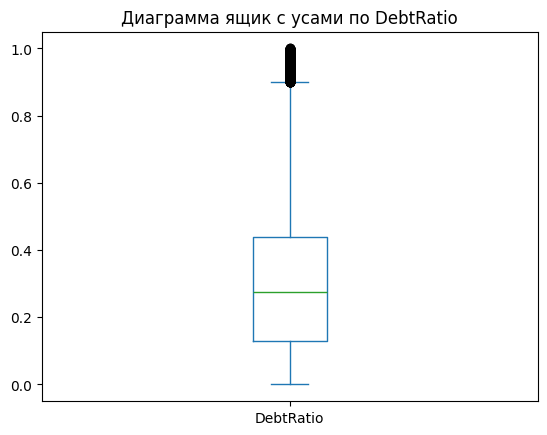

In [14]:
train[train['DebtRatio']<1]['DebtRatio'].plot(kind = 'box')
plt.title('Диаграмма ящик с усами по DebtRatio')
plt.show()

In [15]:
print(f"Количество записей по DebtRatio в интервале от 0.01 до 1: {train[train['DebtRatio'].between(0.01, 1)].shape[0]}")
print(f"Количество записей по DebtRatio в интервале от 1 до 2: {train[train['DebtRatio'].between(1, 2)].shape[0]}")
print(f"Количество записей по DebtRatio в интервале от 2 до 10: {train[train['DebtRatio'].between(2, 10)].shape[0]}")
print(f"Количество записей по DebtRatio = 0: {train[train['DebtRatio'] == 0].shape[0]}")
print(f"Количество записей по DebtRatio в интервале от 10 до 100: {train[train['DebtRatio'].between(10, 100)].shape[0]}")
print(f"Количество записей по DebtRatio в интервале от 100 до 1000: {train[train['DebtRatio'].between(100, 1000)].shape[0]}")
print(f"Количество записей по DebtRatio в интервале от 1000 до 10000: {train[train['DebtRatio'].between(1000, 10000)].shape[0]}")
print(f"Количество записей по DebtRatio в интервале от 10000 до 100000: {train[train['DebtRatio'].between(10000, 100000)].shape[0]}")
print(f"Количество записей по DebtRatio > 100000: {train[train['DebtRatio']> 100000].shape[0]}")
print(f"Количество записей по DebtRatio < 0: {train[train['DebtRatio']<0].shape[0]}")

Количество записей по DebtRatio в интервале от 0.01 до 1: 104258
Количество записей по DebtRatio в интервале от 1 до 2: 4195
Количество записей по DebtRatio в интервале от 2 до 10: 2040
Количество записей по DebtRatio = 0: 3202
Количество записей по DebtRatio в интервале от 10 до 100: 3753
Количество записей по DebtRatio в интервале от 100 до 1000: 6587
Количество записей по DebtRatio в интервале от 1000 до 10000: 15330
Количество записей по DebtRatio в интервале от 10000 до 100000: 162
Количество записей по DebtRatio > 100000: 6
Количество записей по DebtRatio < 0: 0


Стратегия следующая:
1. В столбце DebtRatio существует проблема с размерностью, необходимо привести к одному масштабу.
2. Удалим выбросы в соответствие с бизнес-контекстом таким образом, чтобы размерность исходного датасета не поменялась.
3. В признаках с перекосом данных постараться провести преобразование с целью получить нормальное распределение.

Формализуем подход по DebtRatio.

В виду того, что ~96% от всех данных лежат в промежутке от 0.01 до 2, то логично, что можно привести к данной размерности.

Также видим, что DebtRatio = 0 выглядит недостоверно - вряд ли у заёмщиков отсутствуют траты, сочтём это за то, что он скрывает намеренно от банка. Решение: считаем выбросы записи в том случае, если у таких заёмщиков есть иждивенцы.

In [16]:
def feature_normalizer(df):
  for index in df.index:
        value = df.loc[index, 'DebtRatio']

        if 2 <= value < 10:
            df.loc[index, 'DebtRatio'] /= 10
        elif 10 <= value < 100:
            df.loc[index, 'DebtRatio'] /= 100
        elif 100 <= value < 1000:
            df.loc[index, 'DebtRatio'] /= 1000
        elif 1000 <= value < 10000:
            df.loc[index, 'DebtRatio'] /= 10000
        elif 10000 <= value < 100000:
            df.loc[index, 'DebtRatio'] /= 100000
        elif 100000 <= value < 1e6:
            df.loc[index, 'DebtRatio'] /= 1e6
  return df

train = feature_normalizer(train)
test = feature_normalizer(test)

print(f"Количество записей по DebtRatio в интервале от 0.01 до 2 после преобразования: {train[train['DebtRatio'].between(0.01, 2)].shape[0]}")

Количество записей по DebtRatio в интервале от 0.01 до 2 после преобразования: 135944


In [17]:
train = train[~((train['DebtRatio'] == 0) & (train['NumberOfDependents'] > 0))]
# удаляем только те записи, где отсутствуют траты и есть иждивенцы

In [18]:
def plot_histogram_with_dict(data, column, thresholds, bins=150):
    min_value, max_value = thresholds[column]

    plt.figure(figsize=(10, 6))

    filtered_data = data[column][(data[column] >= min_value) & (data[column] <= max_value)]

    filtered_data.hist(bins=bins, color='skyblue', edgecolor='black')

    plt.title(f'Гистограмма распределения {column} с диапазонами от  {min_value} до {max_value}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

    plt.grid(True)

    plt.show()

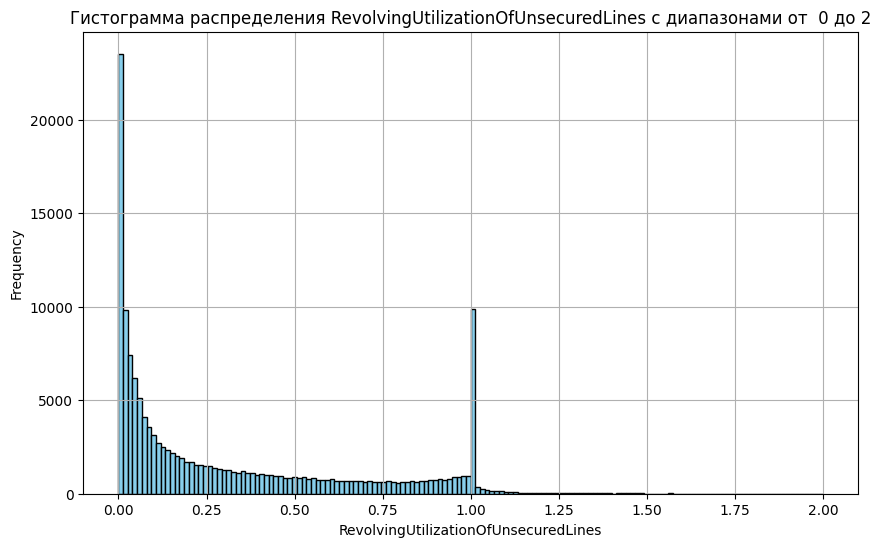

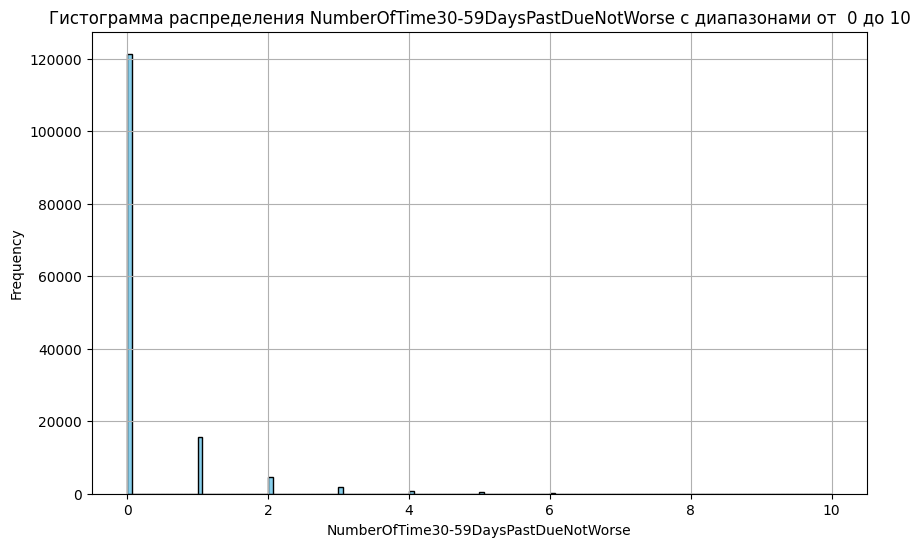

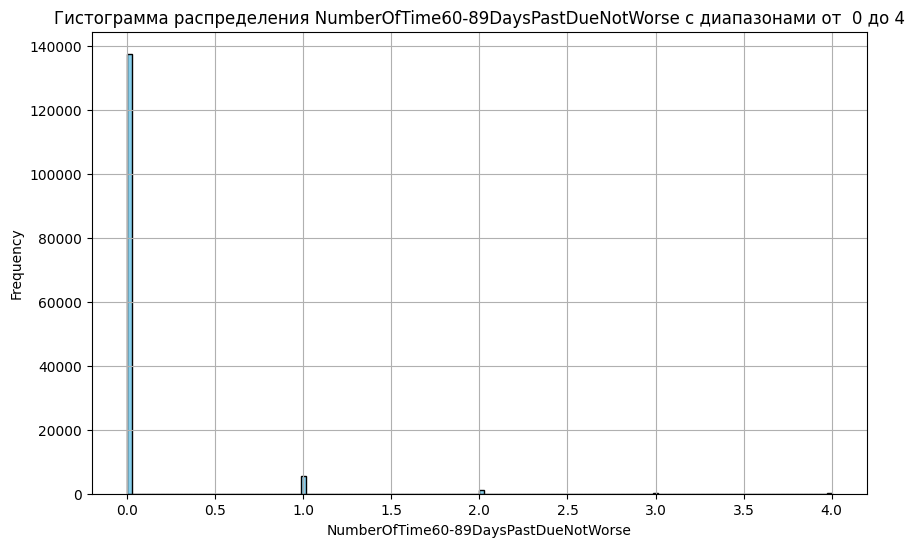

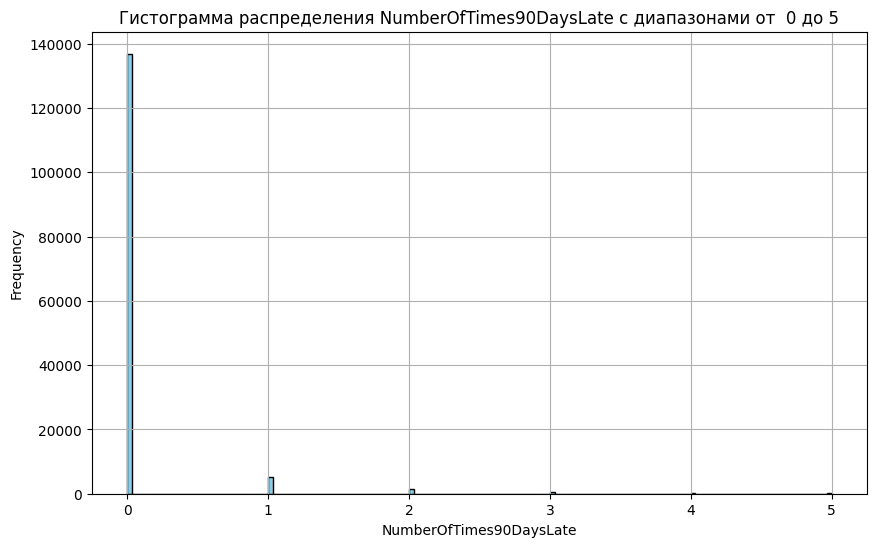

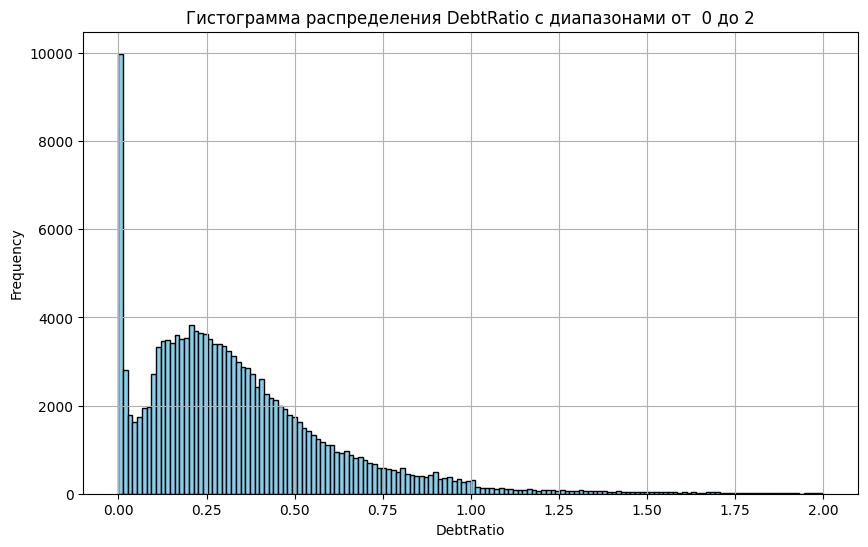

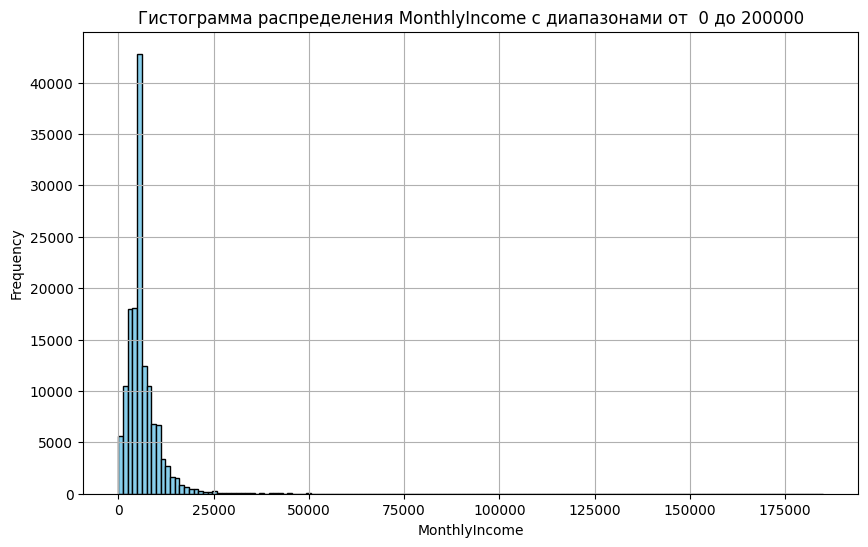

In [19]:
thresholds = {
    "RevolvingUtilizationOfUnsecuredLines": (0, 2),
    "NumberOfTime30-59DaysPastDueNotWorse": (0, 10),
    "NumberOfTime60-89DaysPastDueNotWorse": (0, 4),
    "NumberOfTimes90DaysLate": (0, 5),
    "DebtRatio": (0, 2),
    "MonthlyIncome": (0, 200000)
}

# Пример использования функции
# Подразумевается, что конечно же вы загрузили ваш DataFrame с названием `train` ранее
for column in thresholds.keys():
    plot_histogram_with_dict(train, column, thresholds)

Посмотрим на распределения признаков на диаграмме ящик с усами

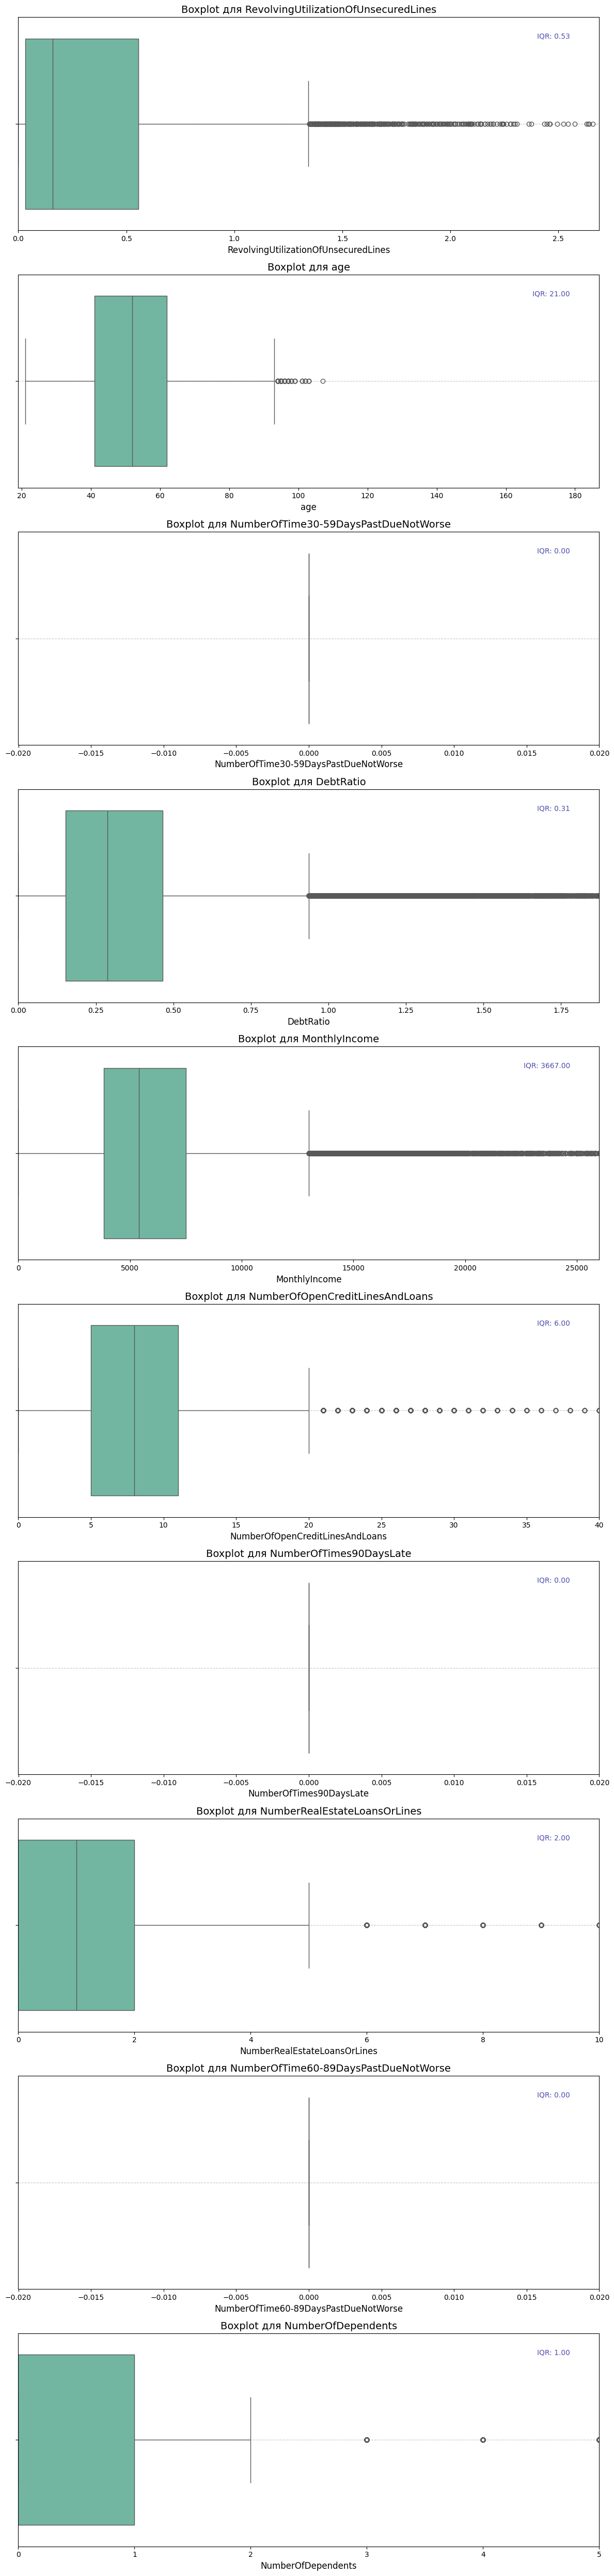

In [20]:
def plot_boxplots_for_features(df):
    num_features = len(df.columns)
    plt.figure(figsize=(12, 5 * num_features))

    for i, feature in enumerate(df.columns):
        ax = plt.subplot(num_features, 1, i + 1)
        df_melt = pd.melt(df, value_vars=[feature])
        sns.boxplot(x=df_melt['value'], palette="Set2", ax=ax)
        ax.set_title(f'Boxplot для {feature}', fontsize=14)
        ax.set_xlabel(f'{feature}', fontsize=12)
        ax.grid(True, axis='y', linestyle='--', alpha=0.7)

        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = max(0, Q1 - 1.5 * IQR)
        upper_bound = Q3 + 1.5 * IQR
        if lower_bound == upper_bound:
            lower_bound -= 0.01
            upper_bound += 0.01
        ax.set_xlim(2*lower_bound, 2*upper_bound)

        ax.annotate(f'IQR: {IQR:.2f}', xy=(0.95, 0.9), xycoords='axes fraction',
                    ha='right', fontsize=10, color='darkblue', alpha=0.7)

    plt.tight_layout()
    plt.show()

target_column = 'SeriousDlqin2yrs'
train_no_target = train.drop(target_column, axis=1)
plot_boxplots_for_features(train_no_target)

In [21]:
print(f"Количество выбросов по признаку RevolvingUtilizationOfUnsecuredLines: {train.shape[0] - train[train['RevolvingUtilizationOfUnsecuredLines'].between(0, 2)].shape[0]}")
print(f"Количество выбросов по признаку age: {train.shape[0] - train[train['age'].between(18, 93)].shape[0]}")
print(f"Количество выбросов по признаку MonthlyIncome: {train[~(train['MonthlyIncome']< 1e5)].shape[0]}")
print(f"Количество выбросов по признаку NumberOfTime30-59DaysPastDueNotWorse: {train.shape[0] - train[train['NumberOfTime30-59DaysPastDueNotWorse'].between(0, 8)].shape[0]}")
print(f"Количество выбросов по признаку NumberOfTime60-89DaysPastDueNotWorse: {train.shape[0] - train[train['NumberOfTime60-89DaysPastDueNotWorse'].between(0, 6)].shape[0]}")
print(f"Количество выбросов по признаку NumberOfTime60-89DaysPastDueNotWorse: {train.shape[0] - train[train['NumberOfTimes90DaysLate'].between(0, 4)].shape[0]}")
print(f"Количество выбросов по признаку NumberRealEstateLoansOrLines: {train.shape[0] - train[train['NumberRealEstateLoansOrLines'].between(0, 10)].shape[0]}")
print(f"Количество выбросов по признаку NumberOfDependents: {train.shape[0] - train[train['NumberOfDependents'].between(0, 6)].shape[0]}")

Количество выбросов по признаку RevolvingUtilizationOfUnsecuredLines: 356
Количество выбросов по признаку age: 116
Количество выбросов по признаку MonthlyIncome: 77
Количество выбросов по признаку NumberOfTime30-59DaysPastDueNotWorse: 189
Количество выбросов по признаку NumberOfTime60-89DaysPastDueNotWorse: 182
Количество выбросов по признаку NumberOfTime60-89DaysPastDueNotWorse: 473
Количество выбросов по признаку NumberRealEstateLoansOrLines: 92
Количество выбросов по признаку NumberOfDependents: 87


Рассмотрим детально 2 признака:
- Количество открытых кредитов (автокредит или ипотека) и кредитных линий (например, кредитные карты);
- Количество займов под недвижимость, включая кредитные линии на недвижимость.

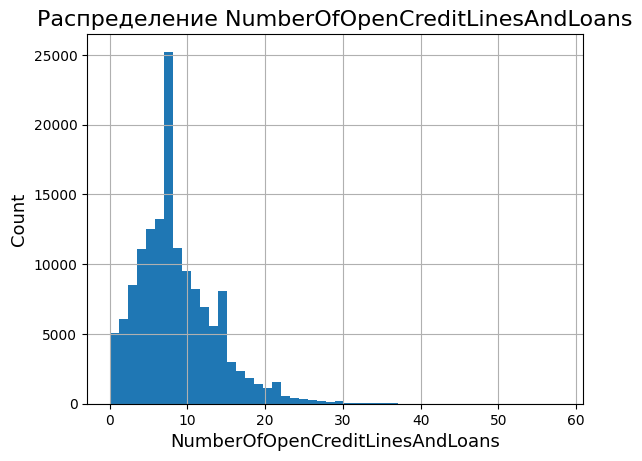

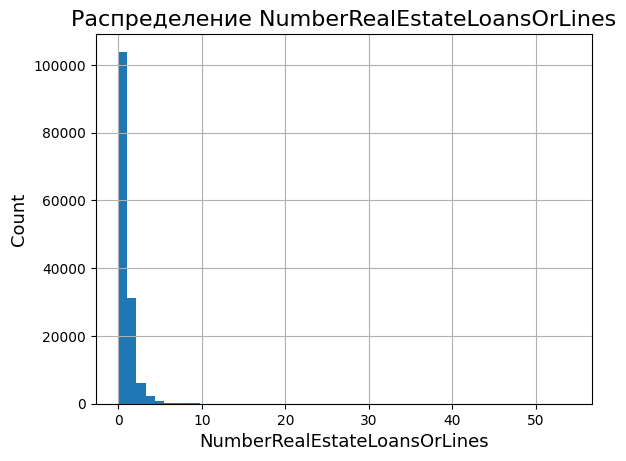

In [22]:
sel_cols = train[['NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines']]

for col in sel_cols:
    plt.figure()
    h = train[col].hist(bins=50)
    h.set_title("Распределение " + col, size=16)
    h.set_xlabel(col, size=13)
    h.set_ylabel('Count', size=13)
    h.get_figure()

Обратим внимание, что в признаке кол-во займов на недвижимость наблюдается экспоненциальное распределение - вполне логично, не так много людей брали несколько кредитов на недвижимость.

In [23]:
print(f"Размер трейна до удаления выбросов: {train.shape[0]}")

def filter_outliers(df):
    conditions = [
        df['RevolvingUtilizationOfUnsecuredLines'].between(0, 2) | df['RevolvingUtilizationOfUnsecuredLines'].isna(),
        df['age'].between(18, 93) | df['age'].isna(),
        (df['MonthlyIncome'] < 1e5) | df['MonthlyIncome'].isna(),
        df['NumberOfTime30-59DaysPastDueNotWorse'].between(0, 8) | df['NumberOfTime30-59DaysPastDueNotWorse'].isna(),
        df['NumberOfTime60-89DaysPastDueNotWorse'].between(0, 6) | df['NumberOfTime60-89DaysPastDueNotWorse'].isna(),
        df['NumberOfTimes90DaysLate'].between(0, 4) | df['NumberOfTimes90DaysLate'].isna(),
        df['NumberRealEstateLoansOrLines'].between(0, 10) | df['NumberRealEstateLoansOrLines'].isna(),
        df['NumberOfDependents'].between(0, 6) | df['NumberOfDependents'].isna()
    ]

    filtered_df = df[np.logical_and.reduce(conditions)]
    return filtered_df

train = filter_outliers(train)

print(f"Размер трейна после фильтрации: {train.shape[0]}")

Размер трейна до удаления выбросов: 144854
Размер трейна после фильтрации: 143639


В рамках предобработки данных осталось привести 3 этапа:

- Привести необходимые столбцы к нормальному распределению путём логарифмирования
- Рассмотреть подходы к решению дисбаланса классов
- Стандартизировать данные перед обучением модели

In [24]:
skewed_features = ["NumberOfTime30-59DaysPastDueNotWorse", "DebtRatio", "MonthlyIncome", "NumberOfTimes90DaysLate", "NumberOfTime60-89DaysPastDueNotWorse"]

cols_to_log = ['NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'RevolvingUtilizationOfUnsecuredLines'] + skewed_features
train[cols_to_log] = np.log(train[cols_to_log] + 1)

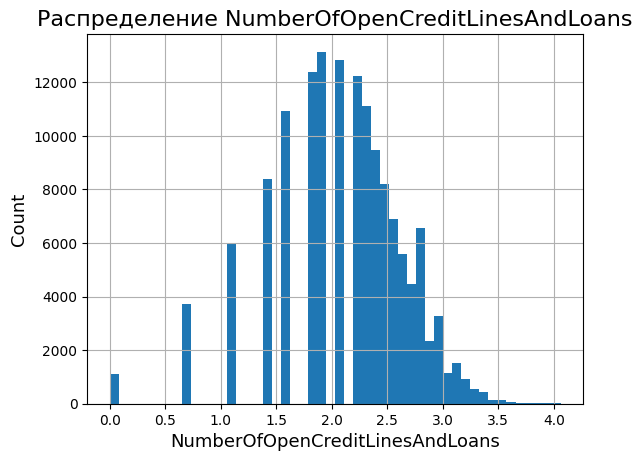

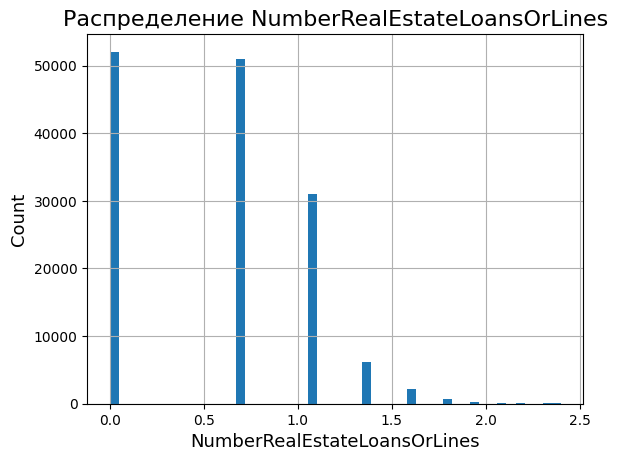

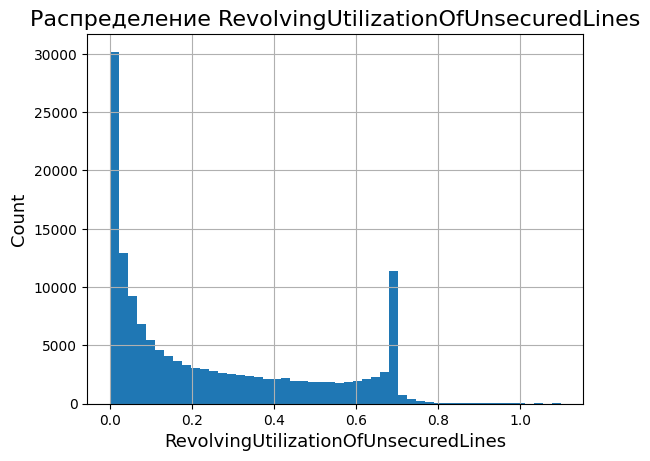

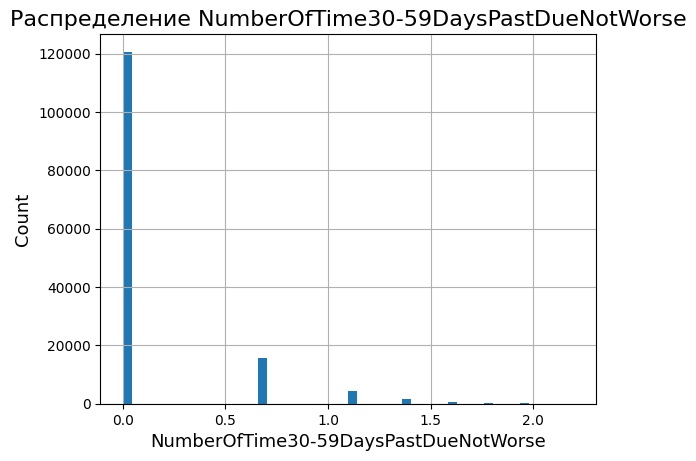

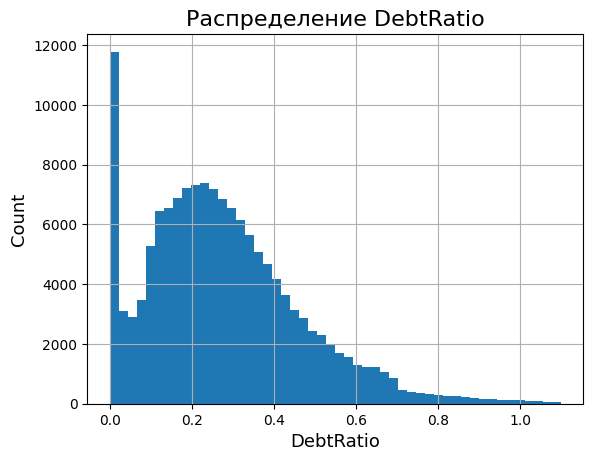

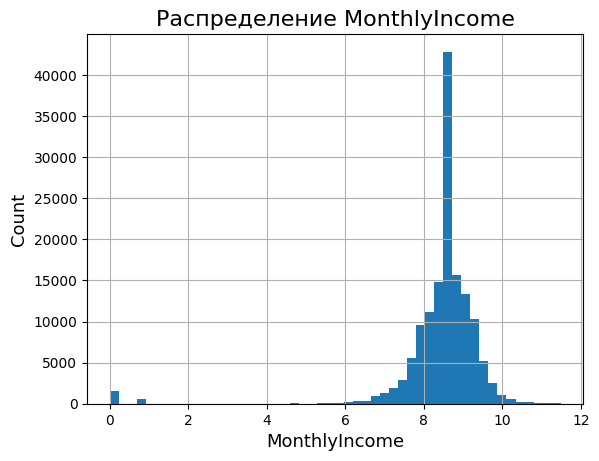

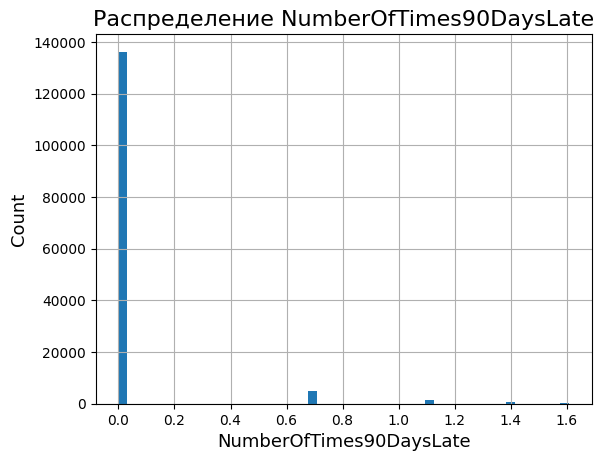

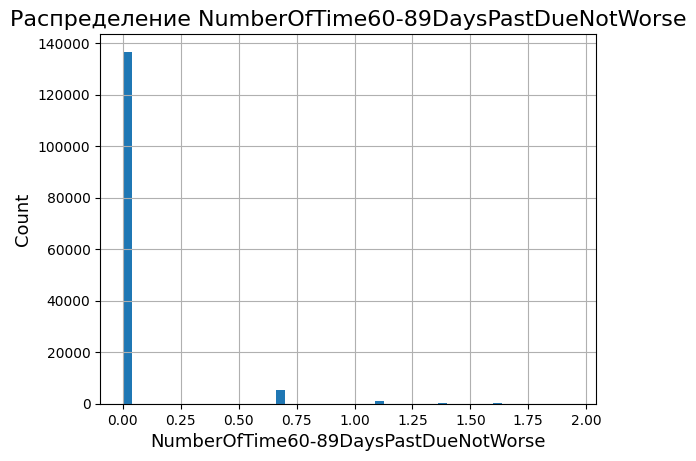

In [25]:
for col in cols_to_log:
    plt.figure()
    h = train[col].hist(bins=50)
    h.set_title("Рaспределение " + col, size = 16)
    h.set_xlabel(col, size = 13)
    h.set_ylabel('Count', size = 13)
    h.get_figure()

Также важным аспектом в задаче построения скоринговой модели является дисбаланс классов.

Подходы к решению проблемы дисбаланса классов:

-  Oversampling: дублируем меньший класс до тех пор, пока классов не станет поровну.
-  Undersampling: идея та же, но уменьшаем бОльший класс.
- SMOTE: продвинутый подход - по сути, представляет собой улучшенный Oversampling. Преимущество метода - классы с меньшей долей компенсируются не просто полным дублированием, а линейной комбинацией.
- ADASYN: похож на SMOTE, но особенность данного метода в том, что он генерирует объекты рядом с исходными объектами, которые были неверно классфицированы при помощи KNN. Обучаем KNN и смотрим на объектах меньшего класса, где был неверно дан прогноз и затем уже происходит генерация.
- Tomek links: базирован на Undersampling. Идея в том, что метод находит 2 близких объекта разных классов и удаляет бОльший по доле класс.
- SMOTEK: комбинация методов SMOTE + Tomeklinks. Сначала Oversampling (SMOTE), затем Undersampling (Tomek links)
- Class weights: задаём веса согласно распределению классов. В моём понимании - приоритетный метод, поскольку подходы выше глобально основаны на 2-ух подходах - уменьшить данные (плохо для обучения модели), либо разными хитрыми/примитивными способами создать синтетические данные, которые фактически не дают новой информации, более того, могут даже не отражать реальность.

В качестве подхода рассмотрим SMOTE и class_weights, поскольку изначально данных не так много, а урезать датасет до уровня положительного класса нецелесообразно.

In [26]:
X = train.drop('SeriousDlqin2yrs', axis=1)
y = train['SeriousDlqin2yrs']

X_test = test
# в y_test уже было записано ранее.


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

В качестве бейзлайна используем логистическую регрессию, так как она может честно предсказывать вероятности, но сначала нужно стандартизировать данные. Далее рассмотрим качество модели с балансировкой весов в логистической регрессии и вариацию OverSampling на той же логистической регрессии и сравним полученные результаты.

In [27]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Модель 1. Логистическая регрессия на сбалансированных классах.


In [28]:
logreg = LogisticRegression(class_weight = 'balanced', max_iter=1000, n_jobs = -1, random_state = 42)
logreg.fit(X_train, y_train)


y_val_pred = logreg.predict(X_val)
y_val_prob = logreg.predict_proba(X_val)[:, 1]

auc_roc = roc_auc_score(y_val, y_val_prob)
gini = 2 * auc_roc - 1
precision = round(precision_score(y_val, y_val_pred), 3)
recall = round(recall_score(y_val, y_val_pred), 2)
f1 = round(f1_score(y_val, y_val_pred), 2)
pr_auc = average_precision_score(y_val, y_val_prob)

print(f"Метрики логистической регрессии с балансировкой весов на валидационной выборке")
print(f'AUC-ROC: {round(auc_roc, 2)}')
print(f'Gini: {round(gini, 2)}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1}')
print(f"PR-AUC: {pr_auc:.2f}")
print("Classification Report:\n", classification_report(y_val, y_val_pred))

Метрики логистической регрессии с балансировкой весов на валидационной выборке
AUC-ROC: 0.85
Gini: 0.69
Precision: 0.2
Recall: 0.72
F1-Score: 0.31
PR-AUC: 0.37
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.80      0.88     26862
           1       0.20      0.72      0.31      1866

    accuracy                           0.79     28728
   macro avg       0.59      0.76      0.60     28728
weighted avg       0.93      0.79      0.84     28728



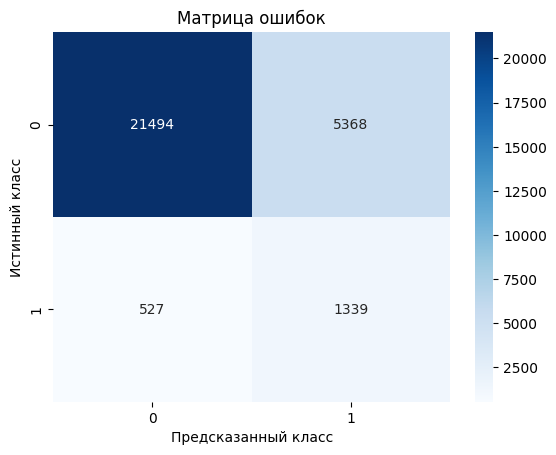

In [29]:
sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt='d', cmap='Blues')

plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()

Исходя из матрицы ошибок видим, что модель склонна допускать ошибку 1-го рода

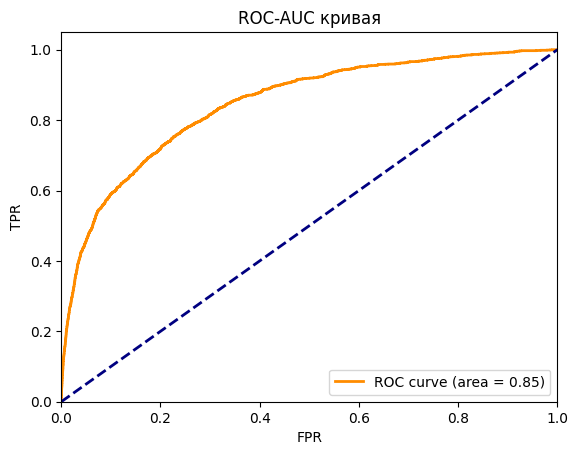

In [30]:
fpr, tpr, thresholds = roc_curve(y_val, y_val_prob)
roc_auc = auc(fpr, tpr)


plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC-AUC кривая')
plt.legend(loc='lower right')
plt.show()

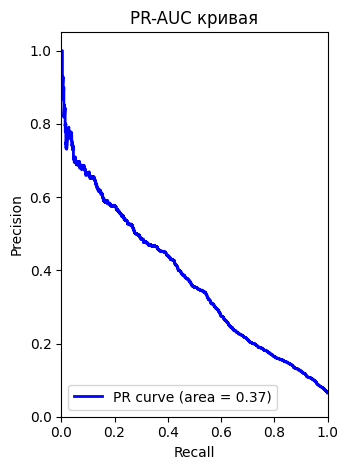

In [31]:
precision, recall, pr_thresholds = precision_recall_curve(y_val, y_val_prob)
pr_auc = auc(recall, precision)

plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-AUC кривая')
plt.legend(loc='lower left')


plt.tight_layout()
plt.show()

Обучим логистическую регрессию на сбалансированных классах и подбором гиперпараметров

In [32]:
logreg_upd = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

param_grid = {
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear'],
        'C': [0.01, 0.1, 1, 10, 100]
    }

grid_search = GridSearchCV(
    logreg_upd,
    param_grid,
    cv=5,
    scoring='average_precision',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_logreg = grid_search.best_estimator_

y_val_probs = best_logreg.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.0, 1.0, 0.01)

best_f1 = 0
best_threshold = 0.5

for threshold in thresholds:
    y_val_pred = (y_val_probs >= threshold).astype(int)

    current_f1 = f1_score(y_val, y_val_pred)

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

y_val_pred_best = (y_val_probs >= best_threshold).astype(int)

precision = precision_score(y_val, y_val_pred_best)
recall = recall_score(y_val, y_val_pred_best)
f1 = f1_score(y_val, y_val_pred_best)

auc_roc = roc_auc_score(y_val, y_val_probs)
gini = 2 * auc_roc - 1
pr_auc = average_precision_score(y_val, y_val_probs)

print("Лучший порог:", round(best_threshold, 2))
print("Лучшие параметры:", grid_search.best_params_)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")
print(f"AUC-ROC: {auc_roc:.2f}")
print(f'Gini: {round(gini, 2)}')
print(f"PR-AUC: {pr_auc:.2f}")

print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_best))

Лучший порог: 0.82
Лучшие параметры: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Precision: 0.43
Recall: 0.42
F1-score: 0.42
AUC-ROC: 0.85
Gini: 0.69
PR-AUC: 0.37

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.96      0.96     26862
           1       0.43      0.42      0.42      1866

    accuracy                           0.93     28728
   macro avg       0.69      0.69      0.69     28728
weighted avg       0.93      0.93      0.93     28728



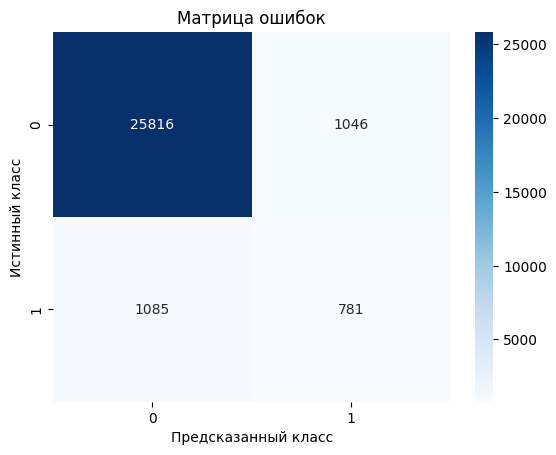

In [33]:
sns.heatmap(confusion_matrix(y_val, y_val_pred_best), annot=True, fmt='d', cmap='Blues')

plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()

Замечаем, что ошибки первого рода стало гораздо меньше, более того, модель стала лучше распознавать недефолтных клиентов.

Теперь обучим модель логистической регрессии после OverSampling методом SMOTE.

In [34]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Исходный тренировочный набор классов:", y_train.value_counts(normalize = True))
print("Набор классов после SMOTE:", y_train_resampled.value_counts(normalize = True))

Исходный тренировочный набор классов: SeriousDlqin2yrs
0    0.935045
1    0.064955
Name: proportion, dtype: float64
Набор классов после SMOTE: SeriousDlqin2yrs
0    0.5
1    0.5
Name: proportion, dtype: float64


In [35]:
logreg_upd_smote = LogisticRegression(random_state=42, max_iter=1000)
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'solver': ['liblinear', 'saga'],
    'l1_ratio': [0, 0.5, 1]
}


grid_search = GridSearchCV(logreg_upd_smote, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_resampled, y_train_resampled)

best_logreg = grid_search.best_estimator_
y_val_probs = best_logreg.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.0, 1.0, 0.01)
best_f1 = 0
best_threshold = 0.5

for current_threshold in thresholds:
    y_val_pred_thresholded = (y_val_probs >= current_threshold).astype(int)
    current_f1 = f1_score(y_val, y_val_pred_thresholded)
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = current_threshold

# Предсказания с использованием оптимального порога
y_val_pred_best = (y_val_probs >= best_threshold).astype(int)

# Метрики
precision = precision_score(y_val, y_val_pred_best)
recall = recall_score(y_val, y_val_pred_best)
f1 = f1_score(y_val, y_val_pred_best)
pr_auc = average_precision_score(y_val, y_val_probs)
auc_roc = roc_auc_score(y_val, y_val_probs)

print("Лучший порог:", round(best_threshold, 2))
print("Лучшие параметры модели:", grid_search.best_params_)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print(f"AUC-ROC: {auc_roc:.2f}")
print(f"PR-AUC: {pr_auc:.2f}")
print("Classification Report:\n", classification_report(y_val, y_val_pred_best))

Лучший порог: 0.83
Лучшие параметры модели: {'C': 0.01, 'l1_ratio': 0, 'penalty': 'l2', 'solver': 'liblinear'}
Precision: 0.436676217765043
Recall: 0.40836012861736337
F1-Score: 0.42204375519246745
AUC-ROC: 0.84
PR-AUC: 0.37
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96     26862
           1       0.44      0.41      0.42      1866

    accuracy                           0.93     28728
   macro avg       0.70      0.69      0.69     28728
weighted avg       0.93      0.93      0.93     28728



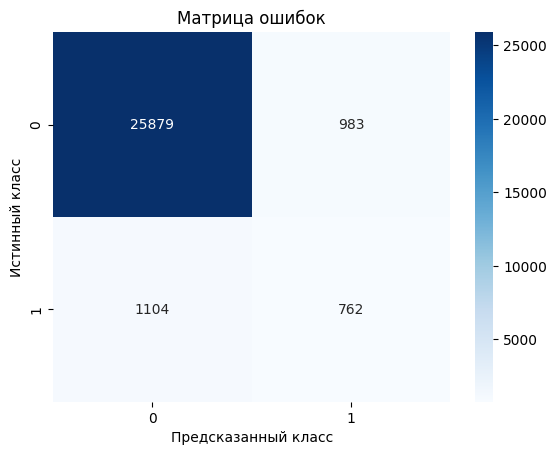

In [36]:
sns.heatmap(confusion_matrix(y_val, y_val_pred_best), annot=True, fmt='d', cmap='Blues')

plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()

Оценим теперь бустинги

In [37]:
catboost = CatBoostClassifier(
    random_state=42,
    verbose=0,
    auto_class_weights="Balanced"
)


param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'iterations': [100, 200]
}


grid_search = GridSearchCV(estimator= catboost,
                           param_grid=param_grid,
                           scoring='f1',
                           cv=5,
                           n_jobs=-1,
                           error_score='raise')


grid_search.fit(X_train, y_train)


best_model = grid_search.best_estimator_


y_val_probs = best_model.predict_proba(X_val)[:, 1]


thresholds = np.arange(0.0, 1.0, 0.01)
best_f1 = 0
best_threshold = 0.5

for current_threshold in thresholds:
    y_val_pred_thresholded = (y_val_probs >= current_threshold).astype(int)
    current_f1 = f1_score(y_val, y_val_pred_thresholded)
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = current_threshold


y_val_pred_best = (y_val_probs >= best_threshold).astype(int)


precision = precision_score(y_val, y_val_pred_best)
recall = recall_score(y_val, y_val_pred_best)
f1 = f1_score(y_val, y_val_pred_best)
pr_auc = average_precision_score(y_val, y_val_probs)
auc_roc = roc_auc_score(y_val, y_val_probs)
gini = 2 * auc_roc - 1


print("Лучший порог:", round(best_threshold, 2))
print("Лучшие параметры модели:", grid_search.best_params_)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print(f"AUC-ROC: {auc_roc:.2f}")
print(f"Gini: {gini:.2f}")
print(f"PR-AUC: {pr_auc:.2f}")
print("Classification Report:\n", classification_report(y_val, y_val_pred_best))

Лучший порог: 0.76
Лучшие параметры модели: {'depth': 8, 'iterations': 200, 'learning_rate': 0.2}
Precision: 0.3643010752688172
Recall: 0.45391211146838156
F1-Score: 0.4041994750656168
AUC-ROC: 0.84
Gini: 0.67
PR-AUC: 0.35
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95     26862
           1       0.36      0.45      0.40      1866

    accuracy                           0.91     28728
   macro avg       0.66      0.70      0.68     28728
weighted avg       0.92      0.91      0.92     28728



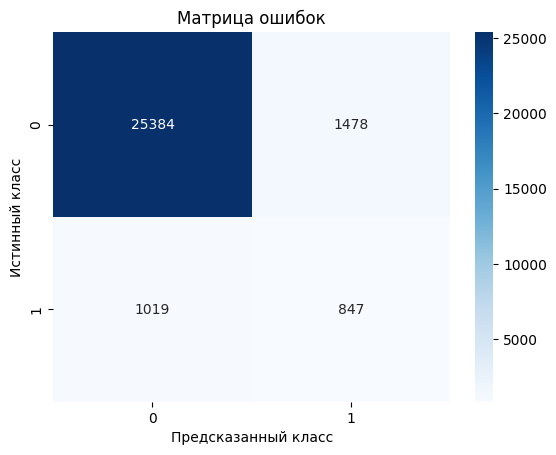

In [38]:
sns.heatmap(confusion_matrix(y_val, y_val_pred_best), annot=True, fmt='d', cmap='Blues')

plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()

Заметим, что кол-во ложноположительных ответов выше, чем у аналогичной вариации в логистической регресии

In [39]:
catboost = CatBoostClassifier(random_state=42, verbose=0)

param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'iterations': [100, 200]
}


grid_search = GridSearchCV(estimator= catboost,
                           param_grid=param_grid,
                           scoring='f1',
                           cv=5,
                           n_jobs=-1,
                           error_score='raise')


grid_search.fit(X_train_resampled, y_train_resampled)


best_model = grid_search.best_estimator_


y_val_probs = best_model.predict_proba(X_val)[:, 1]


thresholds = np.arange(0.0, 1.0, 0.01)
best_f1 = 0
best_threshold = 0.5

for current_threshold in thresholds:
    y_val_pred_thresholded = (y_val_probs >= current_threshold).astype(int)
    current_f1 = f1_score(y_val, y_val_pred_thresholded)
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = current_threshold


y_val_pred_best = (y_val_probs >= best_threshold).astype(int)


precision = precision_score(y_val, y_val_pred_best)
recall = recall_score(y_val, y_val_pred_best)
f1 = f1_score(y_val, y_val_pred_best)
pr_auc = average_precision_score(y_val, y_val_probs)
auc_roc = roc_auc_score(y_val, y_val_probs)
gini = 2 * auc_roc - 1


print("Лучший порог:", round(best_threshold, 2))
print("Лучшие параметры модели:", grid_search.best_params_)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print(f"AUC-ROC: {auc_roc:.2f}")
print(f"Gini: {gini:.2f}")
print(f"PR-AUC: {pr_auc:.2f}")
print("Classification Report:\n", classification_report(y_val, y_val_pred_best))

Лучший порог: 0.29
Лучшие параметры модели: {'depth': 8, 'iterations': 200, 'learning_rate': 0.2}
Precision: 0.38014638609332113
Recall: 0.4453376205787781
F1-Score: 0.41016781836130306
AUC-ROC: 0.84
Gini: 0.68
PR-AUC: 0.34
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96     26862
           1       0.38      0.45      0.41      1866

    accuracy                           0.92     28728
   macro avg       0.67      0.70      0.68     28728
weighted avg       0.92      0.92      0.92     28728



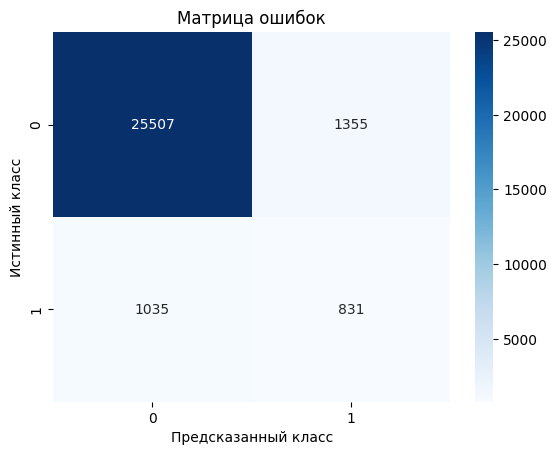

In [40]:
sns.heatmap(confusion_matrix(y_val, y_val_pred_best), annot=True, fmt='d', cmap='Blues')

plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()

Краткие итоги:


1. Логистическая регрессия является быстрым и честным (поскольку корректно предсказывает вероятности) методом классификации, подходит в качестве бейзлайна, для улучшения качества предсказаний можно попробовать различные бустинги, однако там нужно быть более внимательным в вопросе интерпретируемости, поскольку вероятность истинная ≠ уверенность модели.


2. В задачах классификации особенно важно подбирать порог, поскольку в логистической регрессии без параметров стоит 0.5, однако с точки зрения рисков и справедливости оценки модели нужно регулировать данные пороги. Как было использовано выше - за подбор оптимального порога отвечал F1.

Мысли: существует также метрика, как взвешенный F1, которая будет в большей мере учитывать, как бизнес-, так и риск- контекст.

Например, бОльшая доля Recall будет выявлять большую часть дефолтных клиентов, снижая риск финансовых потерь от невозврата. Тогда как бОльшая доля Precision будет способствовать большему валовому доходу от уменьшения потенциального порога для заёмщика, тем самым, повышая удовлетворенность клиентов и потенциальную выручку для банка.

**Промежуточные выводы по данному набору данных**

Объём данных: общая размерность набора данных составляет ~251к записей на 11 полей - для задачи прогнозирования такой объём не является удовлетворительным (особенно, если исследовать нейросетевой подход), поэтому предлагается дообогатить существующий набор данных при помощи метода TabGAN

https://github.com/Diyago/Tabular-data-generation

**GAN** (Generative Adversarial Network): В основе лежит архитектура генеративно-состязательной сети, состоящая из двух нейросетей — генератора (создает данные) и дискриминатора (отличает реальные от фейковых).

Суть библиотеки TabGAN заключается в генерации синтетических табличных данных, которые статистически неотличимы от реального обучающего набора данных, но при этом являются новыми.TabGAN решает проблему нехватки данных (imbalanced/missing data), создавая качественные искусственные примеры, сохраняющие корреляции и распределения исходной таблицы

Модель пытается сохранить:
- распределения;
- корреляции;
- зависимости между колонками.

In [ ]:
X_train = pd.DataFrame(X_train, columns = X.columns)
train_gan = X_train.copy()
train_gan["SeriousDlqin2yrs"] = y_train

generator = GANGenerator(
    gen_x_times=1.0,
    cat_cols=None,
    bot_filter_quantile=0.001,
    top_filter_quantile=0.999,
    is_post_process=True
)

synthetic_train, _ = generator.generate_data_pipe(
    train_gan,
    None,
    None
)

train_augmented = pd.concat(
    [train_gan, synthetic_train],
    axis=0
).reset_index(drop=True)

X_train_augmented = train_augmented.drop(columns=["SeriousDlqin2yrs"])

y_train_augmented = (
    train_augmented["SeriousDlqin2yrs"]
    .round()
    .astype(int)
)

Fitting CTGAN transformers for each column:   0%|          | 0/11 [00:00<?, ?it/s]